In [55]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = 256
BATCH_SIZE = 32
NUM_CLASSES = 11

In [ ]:
import os
import shutil

source_dir = "/kaggle/input/datasets/cookiefinder/tomato-disease-multiple-sources/train"   
target_dir = "/kaggle/working/tomato_dataset"

# Allowed image extensions
valid_ext = (".jpg", ".jpeg", ".png")

os.makedirs(target_dir, exist_ok=True)

for class_name in os.listdir(source_dir):
    class_src = os.path.join(source_dir, class_name)
    class_dst = os.path.join(target_dir, class_name)

    if os.path.isdir(class_src):
        os.makedirs(class_dst, exist_ok=True)

        for file in os.listdir(class_src):
            if file.lower().endswith(valid_ext):  
                src_file = os.path.join(class_src, file)
                dst_file = os.path.join(class_dst, file)
                shutil.copy2(src_file, dst_file)

print("✅ Clean dataset copied (only images)")

In [56]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

In [57]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

/tmp/ipykernel_706/939194944.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
import tensorflow as tf

IMG_SIZE = 224
BATCH_SIZE = 32

full_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/kaggle/working/tomato_dataset",   # your dataset folder
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=123
)

In [ ]:
dataset_size = len(full_ds)
print("Total batches:", dataset_size)

train_size = int(0.7 * dataset_size)
val_size = int(0.2 * dataset_size)

train_ds = full_ds.take(train_size)
val_ds = full_ds.skip(train_size).take(val_size)
test_ds = full_ds.skip(train_size + val_size)

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [58]:
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)

x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model = models.Model(inputs, outputs)

model.summary()

Model: "functional_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_22 (InputLayer)     │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_22 (Sequential)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 8, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,428,491 (9.26 MB)

 Trainable params: 167,947 (656.04 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [61]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2
    )
]

In [62]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/20
646/646 ━━━━━━━━━━━━━━━━━━━━ 79s 96ms/step - accuracy: 0.2783 - loss: 2.4638 - val_accuracy: 0.6559 - val_loss: 1.0392 - learning_rate: 1.0000e-04
Epoch 2/20
646/646 ━━━━━━━━━━━━━━━━━━━━ 71s 94ms/step - accuracy: 0.5711 - loss: 1.3055 - val_accuracy: 0.7168 - val_loss: 0.8207 - learning_rate: 1.0000e-04
Epoch 3/20
646/646 ━━━━━━━━━━━━━━━━━━━━ 71s 93ms/step - accuracy: 0.6294 - loss: 1.0934 - val_accuracy: 0.7445 - val_loss: 0.7473 - learning_rate: 1.0000e-04
Epoch 4/20
646/646 ━━━━━━━━━━━━━━━━━━━━ 71s 93ms/step - accuracy: 0.6773 - loss: 0.9364 - val_accuracy: 0.7594 - val_loss: 0.6923 - learning_rate: 1.0000e-04
Epoch 5/20
646/646 ━━━━━━━━━━━━━━━━━━━━ 71s 94ms/step - accuracy: 0.7089 - loss: 0.8636 - val_accuracy: 0.7730 - val_loss: 0.6651 - learning_rate: 1.0000e-04
Epoch 6/20
646/646 ━━━━━━━━━━━━━━━━━━━━ 71s 94ms/step - accuracy: 0.7353 - loss: 0.7808 - val_accuracy: 0.7824 - val_loss: 0.6250 - learning_rate: 1.0000e-04
Epoch 7/20
646/646 ━━━━━━━━━━━━━━━━━━━━ 72s 94ms/ste

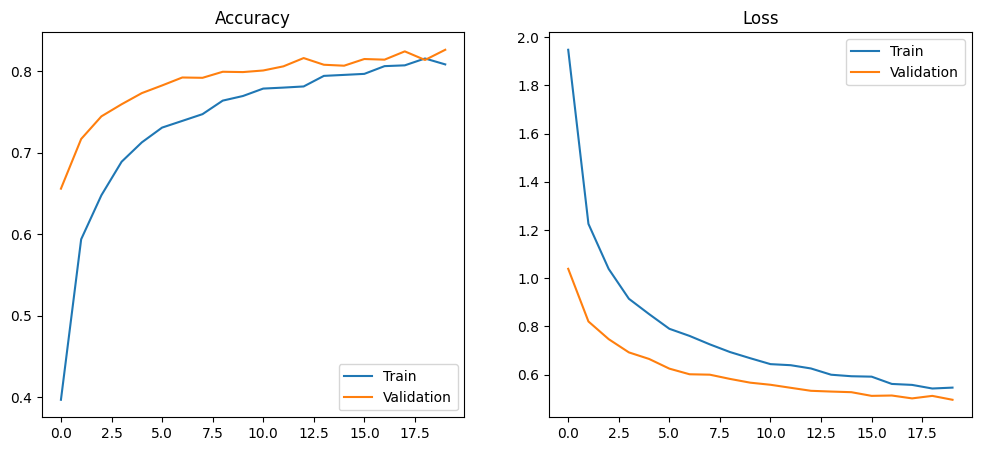

In [63]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()

plt.show()

In [64]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)

81/81 ━━━━━━━━━━━━━━━━━━━━ 18s 70ms/step - accuracy: 0.8221 - loss: 0.5109
Test Accuracy: 0.8225744366645813


In [65]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50
646/646 ━━━━━━━━━━━━━━━━━━━━ 97s 117ms/step - accuracy: 0.7039 - loss: 0.8826 - val_accuracy: 0.7961 - val_loss: 0.6508 - learning_rate: 1.0000e-05
Epoch 2/50
646/646 ━━━━━━━━━━━━━━━━━━━━ 85s 114ms/step - accuracy: 0.7780 - loss: 0.6412 - val_accuracy: 0.8215 - val_loss: 0.5204 - learning_rate: 1.0000e-05
Epoch 3/50
646/646 ━━━━━━━━━━━━━━━━━━━━ 85s 114ms/step - accuracy: 0.8038 - loss: 0.5608 - val_accuracy: 0.8211 - val_loss: 0.5121 - learning_rate: 1.0000e-05
Epoch 4/50
646/646 ━━━━━━━━━━━━━━━━━━━━ 85s 114ms/step - accuracy: 0.8182 - loss: 0.5259 - val_accuracy: 0.8301 - val_loss: 0.4944 - learning_rate: 1.0000e-05
Epoch 5/50
646/646 ━━━━━━━━━━━━━━━━━━━━ 85s 114ms/step - accuracy: 0.8324 - loss: 0.4893 - val_accuracy: 0.8430 - val_loss: 0.4748 - learning_rate: 1.0000e-05
Epoch 6/50
646/646 ━━━━━━━━━━━━━━━━━━━━ 85s 114ms/step - accuracy: 0.8444 - loss: 0.4546 - val_accuracy: 0.8391 - val_loss: 0.5014 - learning_rate: 1.0000e-05
Epoch 7/50
646/646 ━━━━━━━━━━━━━━━━━━━━ 85s 11

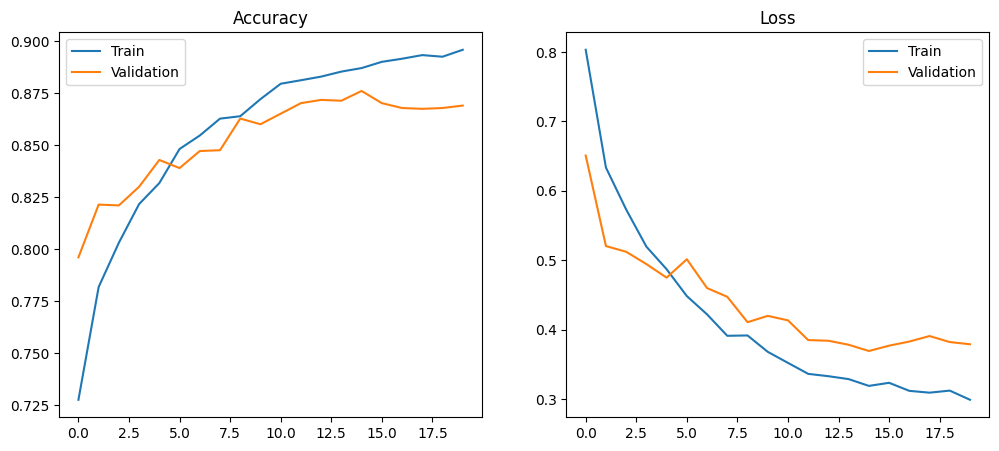

In [66]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_fine.history['accuracy'], label='Train')
plt.plot(history_fine.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_fine.history['loss'], label='Train')
plt.plot(history_fine.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()

plt.show()

In [67]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)

81/81 ━━━━━━━━━━━━━━━━━━━━ 18s 65ms/step - accuracy: 0.8624 - loss: 0.3914
Test Accuracy: 0.8701198101043701


In [68]:
import os

base_path = "/kaggle/working/models"

os.makedirs(base_path, exist_ok=True)

existing = [int(i) for i in os.listdir(base_path) if i.isdigit()]
model_version = max(existing + [0]) + 1

model.save(f"{base_path}/{model_version}.h5")

print(f"Model saved as version {model_version}")

Model saved as version 1
